In [ ]:
import pandas as pd
df = pd.read_csv("/content/heart_cleaned.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,0.481132,0.244292,1,0,0.603053,0,2.3,0,0,1,1
1,37,1,2,0.339623,0.283105,0,1,0.885496,0,3.5,0,0,2,1
2,41,0,1,0.339623,0.178082,0,0,0.770992,0,1.4,2,0,2,1
3,56,1,1,0.245283,0.251142,0,1,0.816794,0,0.8,2,0,2,1
4,57,0,0,0.245283,0.520548,0,1,0.702290,1,0.6,2,0,2,1


#Logistic Regression using Basic GD

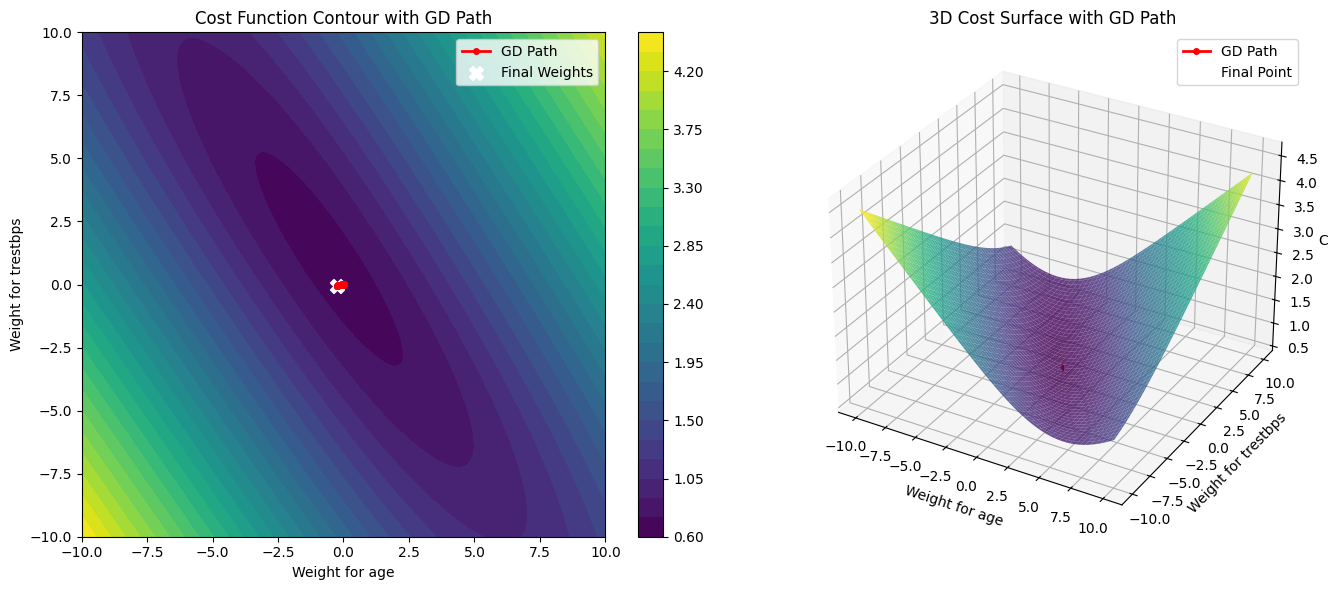

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Use only two features for visualization
features = ["age", "trestbps"]  # change if needed
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale if not already scaled
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1 - y)*np.log(1 - y_hat + 1e-8))

# ------------------ Gradient Descent (recording path) ------------------
def gradient_descent_with_path(X, y, lr=0.1, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    path = [W.copy()]  # store initial weights
    costs = []

    for i in range(epochs):
        z = np.dot(X, W)
        y_hat = sigmoid(z)

        # Gradients
        dw = (1/m) * np.dot(X.T, (y_hat - y))

        # Update weights
        W -= lr * dw

        if i % 5 == 0:  # record every few steps
            cost = compute_cost(y, y_hat)
            costs.append(cost)
            path.append(W.copy())

    return W, np.array(path), costs

# Train model and record path
W, path, costs = gradient_descent_with_path(X_train, y_train, lr=0.1, epochs=200)

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Contour + 3D Plots ------------------
fig = plt.figure(figsize=(14, 6))

# Contour plot with path
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Cost Function Contour with GD Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

# Plot the convergence path
ax1.plot(path[:, 1], path[:, 2], color='red', marker='o', markersize=4, linewidth=2, label='GD Path')
ax1.scatter(W[1], W[2], color='white', marker='X', s=100, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D surface with path
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("3D Cost Surface with GD Path", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# Plot the 3D path
z_path = []
for Wp in path:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))

z_path = np.array(z_path)
ax2.plot(path[:, 1], path[:, 2], z_path, color='red', marker='o', markersize=4, linewidth=2, label='GD Path')
ax2.scatter(W[1], W[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()


The code trains a logistic regression model using two features and records how the weights change during Gradient Descent.

It computes the cost surface over a grid of weight values to visualize how the loss changes.

A 2D contour plot and a 3D surface plot show the Gradient Descent path moving toward the minimum cost.

The visualizations help understand how optimization works and how weights converge during training.

#SGD

Epoch 0 | Cost: 0.6877
Epoch 10 | Cost: 0.6696
Epoch 20 | Cost: 0.6695
Epoch 30 | Cost: 0.6548
Epoch 40 | Cost: 0.6649
Epoch 50 | Cost: 0.6670
Epoch 60 | Cost: 0.6671
Epoch 70 | Cost: 0.6657
Epoch 80 | Cost: 0.6660
Epoch 90 | Cost: 0.6649
Epoch 100 | Cost: 0.6686
Epoch 110 | Cost: 0.6660
Epoch 120 | Cost: 0.6674
Epoch 130 | Cost: 0.6671
Epoch 140 | Cost: 0.6667
Epoch 150 | Cost: 0.6672
Epoch 160 | Cost: 0.6673
Epoch 170 | Cost: 0.6669
Epoch 180 | Cost: 0.6634
Epoch 190 | Cost: 0.6678

✅ Test Accuracy (SGD): 63.93%


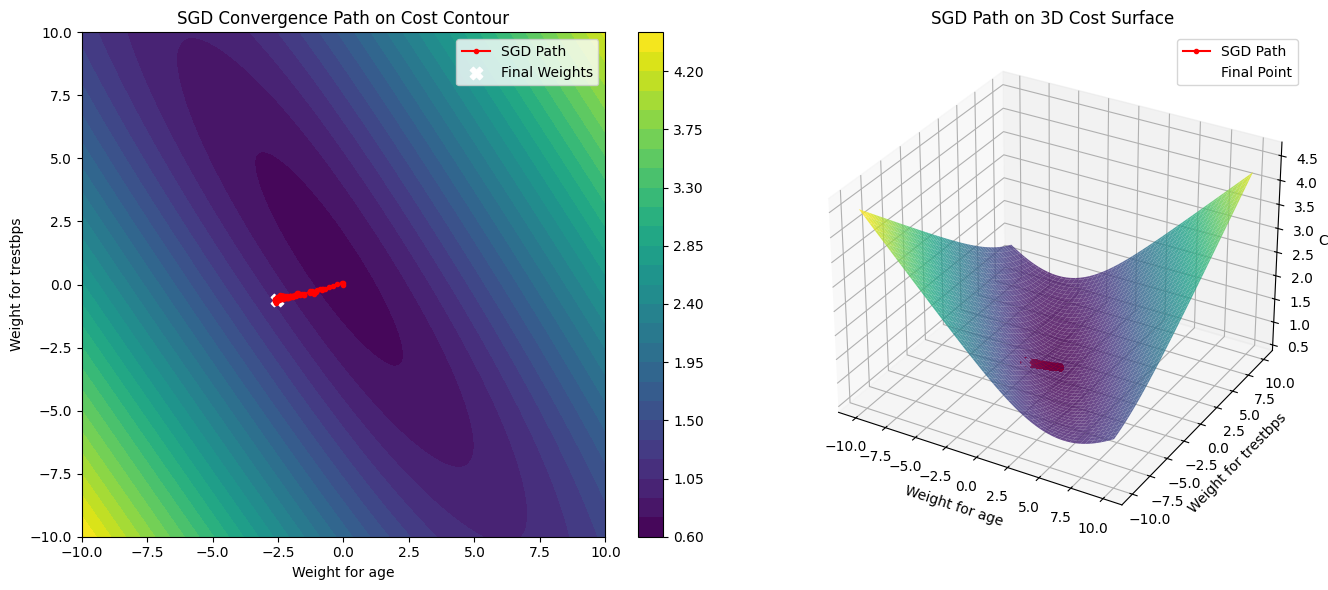

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Select only 2 features for visualization
features = ["age", "trestbps"]   # you can change these two
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features (if not already scaled)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ SGD with path recording ------------------
def stochastic_gradient_descent_with_path(X, y, lr=0.05, epochs=100):
    m, n = X.shape
    W = np.zeros((n, 1))
    costs = []
    path = [W.copy()]  # store initial weights

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        cost_epoch = 0

        for i in indices:
            xi = X[i, :].reshape(1, -1)
            yi = y[i].reshape(1, 1)

            z = np.dot(xi, W)
            y_hat = sigmoid(z)

            dw = np.dot(xi.T, (y_hat - yi))
            W -= lr * dw  # bias term already included in X_b

            cost_epoch += compute_cost(yi, y_hat)

            # Record path occasionally (to avoid too many points)
            if np.random.rand() < 0.005:
                path.append(W.copy())

        cost_epoch /= m
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_sgd, path_sgd, costs_sgd = stochastic_gradient_descent_with_path(X_train, y_train, lr=0.05, epochs=200)

# ------------------ Evaluate ------------------
y_pred_sgd = sigmoid(np.dot(X_test, W_sgd))
y_pred_class_sgd = (y_pred_sgd >= 0.5).astype(int)
accuracy_sgd = np.mean(y_pred_class_sgd == y_test) * 100
print(f"\n✅ Test Accuracy (SGD): {accuracy_sgd:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with SGD Path ------------------
fig = plt.figure(figsize=(14, 6))

# Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("SGD Convergence Path on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

# Path of SGD
ax1.plot(path_sgd[:, 1], path_sgd[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='SGD Path')
ax1.scatter(W_sgd[1], W_sgd[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("SGD Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# 3D Path
z_path = []
for Wp in path_sgd:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_sgd[:, 1], path_sgd[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='SGD Path')
ax2.scatter(W_sgd[1], W_sgd[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()


This code implements Stochastic Gradient Descent (SGD) for logistic regression using two features to make the optimization path visualizable.

The algorithm updates weights one sample at a time, resulting in a noisy but faster convergence path.

A 2D contour plot and a 3D cost surface show how SGD jumps toward the minimum, illustrating its stochastic behavior.

The final accuracy on the test set is measured, and the SGD trajectory is plotted to understand how the weights evolve during training.

#Mini Batch GD

Epoch 0 | Cost: 0.6922
Epoch 10 | Cost: 0.6884
Epoch 20 | Cost: 0.6867
Epoch 30 | Cost: 0.6851
Epoch 40 | Cost: 0.6837
Epoch 50 | Cost: 0.6825
Epoch 60 | Cost: 0.6812
Epoch 70 | Cost: 0.6800
Epoch 80 | Cost: 0.6789
Epoch 90 | Cost: 0.6778
Epoch 100 | Cost: 0.6768
Epoch 110 | Cost: 0.6758
Epoch 120 | Cost: 0.6750
Epoch 130 | Cost: 0.6741
Epoch 140 | Cost: 0.6733
Epoch 150 | Cost: 0.6726
Epoch 160 | Cost: 0.6719
Epoch 170 | Cost: 0.6713
Epoch 180 | Cost: 0.6706
Epoch 190 | Cost: 0.6701

✅ Test Accuracy (Mini-Batch GD): 52.46%


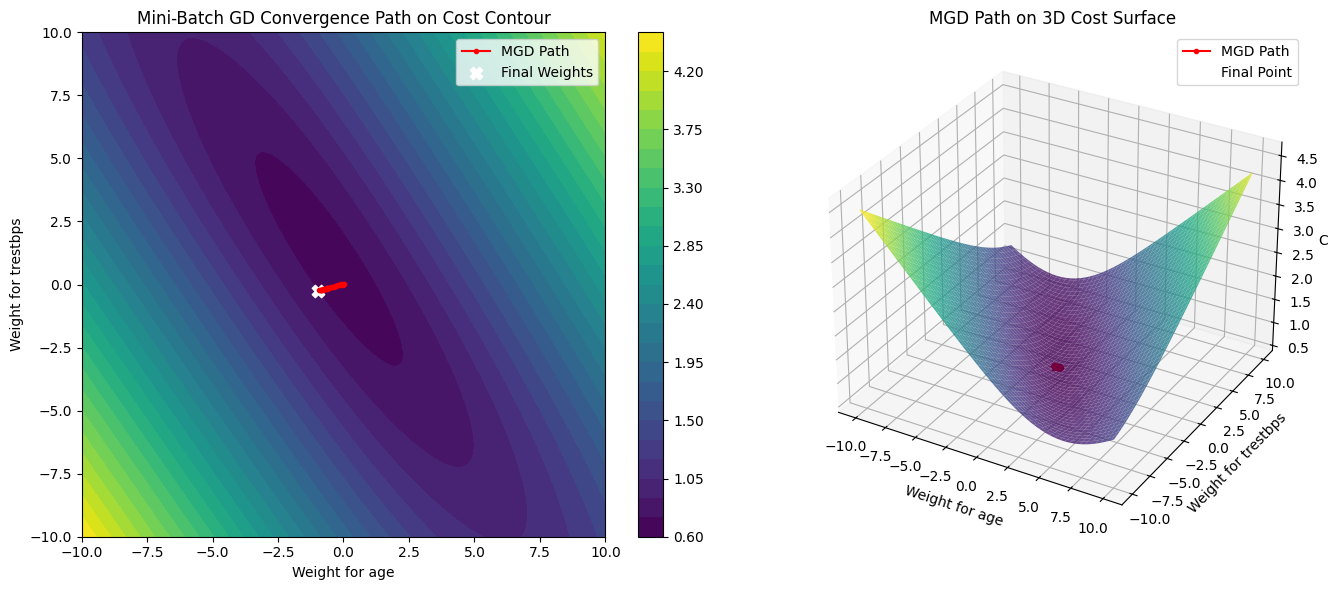

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Select only 2 features for visualization
features = ["age", "trestbps"]  # choose any two numeric features
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features (to [0,1])
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Mini-Batch Gradient Descent ------------------
def mini_batch_gradient_descent_with_path(X, y, lr=0.05, epochs=100, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    costs = []
    path = [W.copy()]  # store initial weights

    for epoch in range(epochs):
        # Shuffle data
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        # Create mini-batches
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Forward pass
            z = np.dot(X_batch, W)
            y_hat = sigmoid(z)

            # Compute gradients
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Update weights
            W -= lr * dw

            # Occasionally store the path (to avoid too many points)
            if np.random.rand() < 0.005:
                path.append(W.copy())

        # Compute cost at epoch end
        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_mgd, path_mgd, costs_mgd = mini_batch_gradient_descent_with_path(X_train, y_train, lr=0.05, epochs=200, batch_size=32)

# ------------------ Evaluate ------------------
y_pred_mgd = sigmoid(np.dot(X_test, W_mgd))
y_pred_class_mgd = (y_pred_mgd >= 0.5).astype(int)
accuracy_mgd = np.mean(y_pred_class_mgd == y_test) * 100
print(f"\n✅ Test Accuracy (Mini-Batch GD): {accuracy_mgd:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with MGD Path ------------------
fig = plt.figure(figsize=(14, 6))

# Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Mini-Batch GD Convergence Path on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

# MGD Path
ax1.plot(path_mgd[:, 1], path_mgd[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='MGD Path')
ax1.scatter(W_mgd[1], W_mgd[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("MGD Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# 3D Path
z_path = []
for Wp in path_mgd:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_mgd[:, 1], path_mgd[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='MGD Path')
ax2.scatter(W_mgd[1], W_mgd[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

This code implements Mini-Batch Gradient Descent for logistic regression, updating weights using small batches (size = 32) for a balance between stability and speed.

The algorithm produces a smoother path than SGD but more flexible and faster than full-batch Gradient Descent.

A contour plot and 3D cost surface visualize how mini-batch updates move the weights toward the minimum.

The final accuracy is computed on the test set, and the MGD trajectory shows the intermediate weight updates during training.

#Momentum

Epoch 0 | Cost: 0.6902
Epoch 10 | Cost: 0.6773
Epoch 20 | Cost: 0.6694
Epoch 30 | Cost: 0.6651
Epoch 40 | Cost: 0.6627
Epoch 50 | Cost: 0.6614
Epoch 60 | Cost: 0.6608
Epoch 70 | Cost: 0.6602
Epoch 80 | Cost: 0.6599
Epoch 90 | Cost: 0.6601
Epoch 100 | Cost: 0.6596
Epoch 110 | Cost: 0.6596
Epoch 120 | Cost: 0.6595
Epoch 130 | Cost: 0.6595
Epoch 140 | Cost: 0.6594
Epoch 150 | Cost: 0.6594
Epoch 160 | Cost: 0.6602
Epoch 170 | Cost: 0.6594
Epoch 180 | Cost: 0.6597
Epoch 190 | Cost: 0.6600

✅ Test Accuracy (Momentum GD): 60.66%


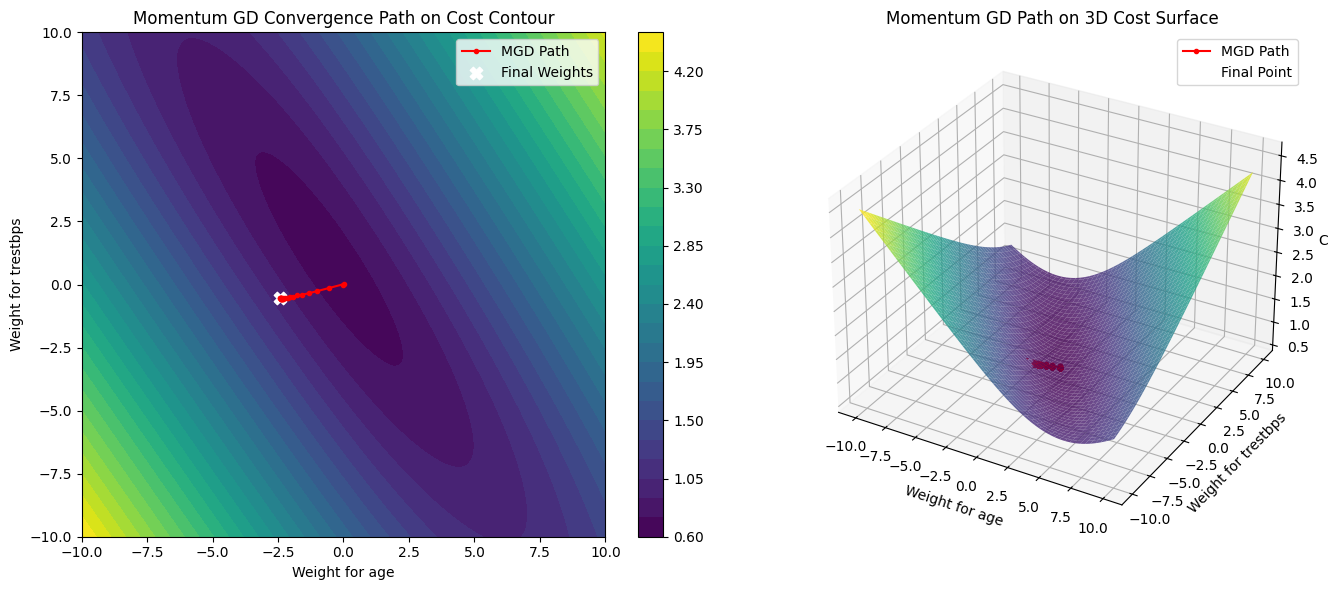

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Momentum Gradient Descent ------------------
def momentum_gradient_descent_with_path(X, y, lr=0.05, gamma=0.9, epochs=200, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    v = np.zeros_like(W)
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Forward pass
            z = np.dot(X_batch, W)
            y_hat = sigmoid(z)
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Update velocity and weights
            v = gamma * v + lr * dw
            W -= v

            if np.random.rand() < 0.005:
                path.append(W.copy())

        # Compute cost for tracking
        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_mgd, path_mgd, costs_mgd = momentum_gradient_descent_with_path(X_train, y_train, lr=0.05, gamma=0.9, epochs=200, batch_size=32)

# ------------------ Evaluate ------------------
y_pred_mgd = sigmoid(np.dot(X_test, W_mgd))
y_pred_class_mgd = (y_pred_mgd >= 0.5).astype(int)
accuracy_mgd = np.mean(y_pred_class_mgd == y_test) * 100
print(f"\n✅ Test Accuracy (Momentum GD): {accuracy_mgd:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with MGD Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Momentum GD Convergence Path on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

ax1.plot(path_mgd[:, 1], path_mgd[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='MGD Path')
ax1.scatter(W_mgd[1], W_mgd[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Momentum GD Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_mgd:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_mgd[:, 1], path_mgd[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='MGD Path')
ax2.scatter(W_mgd[1], W_mgd[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

This code implements Momentum-based Gradient Descent, which adds a velocity term to accelerate updates in the right direction and smooth out oscillations.

The method helps the optimizer move faster along shallow slopes and avoid getting stuck, producing a more stable convergence path than SGD or Mini-Batch GD.

Both contour and 3D cost surface plots show how momentum carries the weights forward, creating a smoother and more directed path toward the minimum.

The final accuracy is computed on the test set, and the momentum trajectory is visualized to illustrate how the velocity term improves optimization efficiency.

#Nestrov Gradient Descent

Epoch 0 | Cost: 0.6902
Epoch 10 | Cost: 0.6770
Epoch 20 | Cost: 0.6699
Epoch 30 | Cost: 0.6654
Epoch 40 | Cost: 0.6628
Epoch 50 | Cost: 0.6616
Epoch 60 | Cost: 0.6606
Epoch 70 | Cost: 0.6603
Epoch 80 | Cost: 0.6598
Epoch 90 | Cost: 0.6601
Epoch 100 | Cost: 0.6596
Epoch 110 | Cost: 0.6596
Epoch 120 | Cost: 0.6595
Epoch 130 | Cost: 0.6594
Epoch 140 | Cost: 0.6596
Epoch 150 | Cost: 0.6594
Epoch 160 | Cost: 0.6594
Epoch 170 | Cost: 0.6594
Epoch 180 | Cost: 0.6595
Epoch 190 | Cost: 0.6609

✅ Test Accuracy (NAG): 62.30%


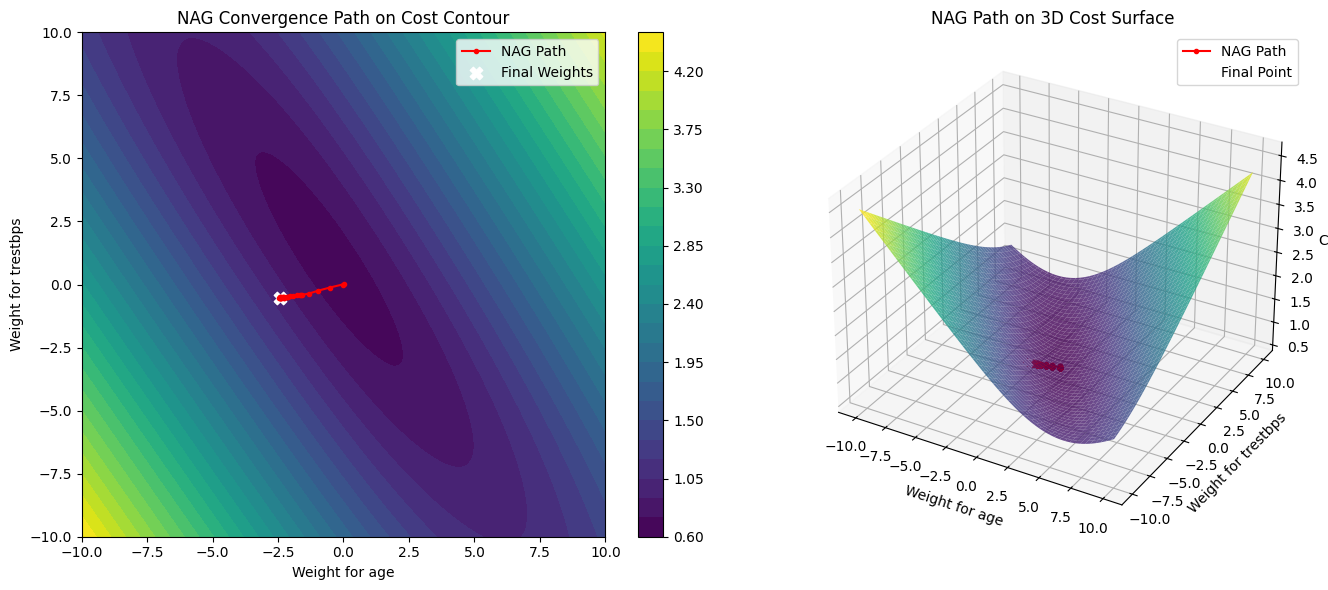

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Nesterov Accelerated Gradient ------------------
def nesterov_accelerated_gradient_with_path(X, y, lr=0.05, gamma=0.9, epochs=200, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    v = np.zeros_like(W)
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Look-ahead weights
            W_lookahead = W - gamma * v

            # Forward + gradient at lookahead position
            z = np.dot(X_batch, W_lookahead)
            y_hat = sigmoid(z)
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Velocity + weight update
            v = gamma * v + lr * dw
            W -= v

            if np.random.rand() < 0.005:
                path.append(W.copy())

        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_nag, path_nag, costs_nag = nesterov_accelerated_gradient_with_path(X_train, y_train, lr=0.05, gamma=0.9, epochs=200, batch_size=32)

# ------------------ Evaluate ------------------
y_pred_nag = sigmoid(np.dot(X_test, W_nag))
y_pred_class_nag = (y_pred_nag >= 0.5).astype(int)
accuracy_nag = np.mean(y_pred_class_nag == y_test) * 100
print(f"\n✅ Test Accuracy (NAG): {accuracy_nag:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with NAG Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("NAG Convergence Path on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

ax1.plot(path_nag[:, 1], path_nag[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='NAG Path')
ax1.scatter(W_nag[1], W_nag[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("NAG Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_nag:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_nag[:, 1], path_nag[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='NAG Path')
ax2.scatter(W_nag[1], W_nag[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

This code implements Nesterov Accelerated Gradient, which performs a look-ahead update before computing the gradient, giving faster and more controlled convergence than standard momentum.

NAG anticipates the future direction of the weights, reducing overshooting and improving stability, especially on curved cost surfaces.

The contour and 3D plots visualize how the NAG trajectory is smoother and more precise compared to Momentum or SGD.

The final model accuracy is measured, and the plotted path shows how NAG efficiently approaches the minimum while reducing oscillations.

#Armijo

Epoch 0 | Cost: 0.6890
Epoch 10 | Cost: 0.6747
Epoch 20 | Cost: 0.6672
Epoch 30 | Cost: 0.6638
Epoch 40 | Cost: 0.6616
Epoch 50 | Cost: 0.6607
Epoch 60 | Cost: 0.6602
Epoch 70 | Cost: 0.6601
Epoch 80 | Cost: 0.6617
Epoch 90 | Cost: 0.6595
Epoch 100 | Cost: 0.6597
Epoch 110 | Cost: 0.6608
Epoch 120 | Cost: 0.6596
Epoch 130 | Cost: 0.6598
Epoch 140 | Cost: 0.6595
Epoch 150 | Cost: 0.6595
Epoch 160 | Cost: 0.6595
Epoch 170 | Cost: 0.6594
Epoch 180 | Cost: 0.6603
Epoch 190 | Cost: 0.6595

✅ Test Accuracy (NAG + Armijo): 60.66%


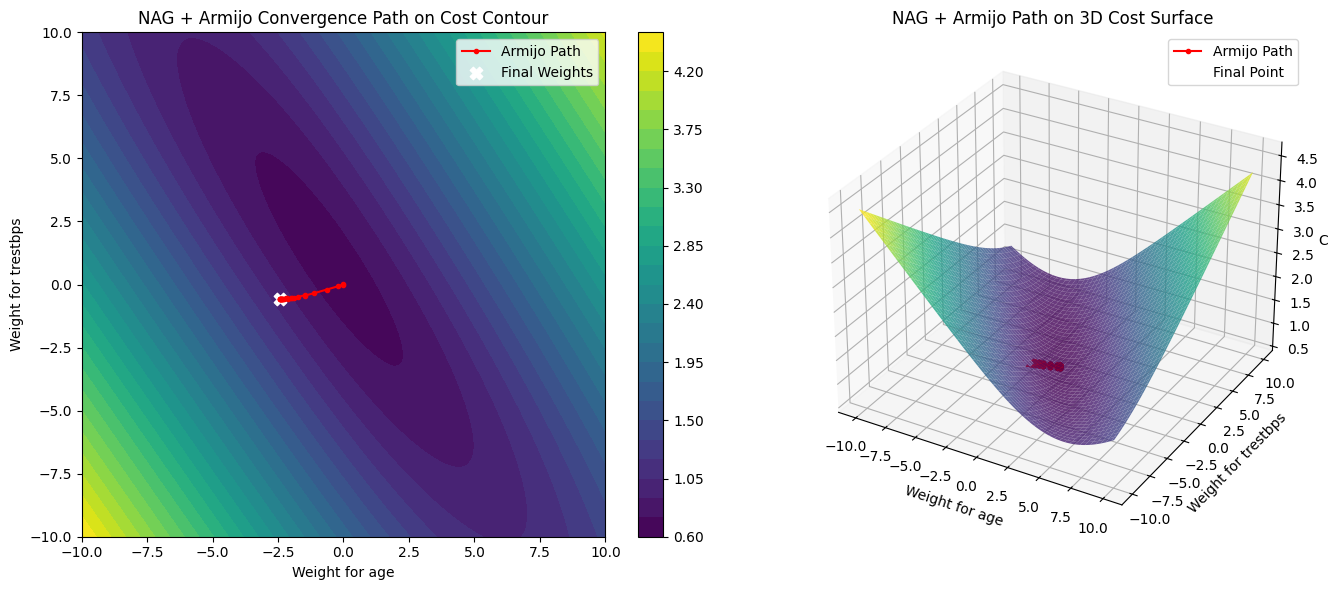

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Armijo Backtracking ------------------
def armijo_backtracking(X, y, W, b, grad_W, grad_b, direction_W, direction_b, alpha=1.0, beta=0.5, sigma=1e-4):
    """
    Performs Armijo backtracking line search.
    Adjusts the step size alpha to ensure sufficient cost reduction.
    """
    m = len(y)
    y_hat = sigmoid(np.dot(X, W) + b)
    cost = compute_cost(y, y_hat)

    # Try smaller steps until cost decreases sufficiently
    while True:
        W_new = W + alpha * direction_W
        b_new = b + alpha * direction_b
        y_hat_new = sigmoid(np.dot(X, W_new) + b_new)
        new_cost = compute_cost(y, y_hat_new)
        if new_cost <= cost + sigma * alpha * np.sum(grad_W * direction_W):
            break
        alpha *= beta  # Reduce step size
    return alpha

# ------------------ NAG with Armijo Rule ------------------
def nesterov_accelerated_gradient_armijo(X, y, lr_init=0.05, gamma=0.9, epochs=200, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    b = 0
    v_W = np.zeros_like(W)
    v_b = 0
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Lookahead position
            W_lookahead = W - gamma * v_W
            b_lookahead = b - gamma * v_b

            # Compute gradients at lookahead
            z = np.dot(X_batch, W_lookahead) + b_lookahead
            y_hat = sigmoid(z)
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))
            db = (1 / X_batch.shape[0]) * np.sum(y_hat - y_batch)

            # Direction (negative gradient)
            direction_W = -dw
            direction_b = -db

            # Compute adaptive learning rate using Armijo rule
            lr = armijo_backtracking(X_batch, y_batch, W, b, dw, db, direction_W, direction_b, alpha=lr_init)

            # Update velocity and weights
            v_W = gamma * v_W + lr * dw
            v_b = gamma * v_b + lr * db
            W -= v_W
            b -= v_b

            if np.random.rand() < 0.005:
                path.append(W.copy())

        # Compute epoch cost
        y_hat_all = sigmoid(np.dot(X, W) + b)
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, b, np.array(path), costs

# ------------------ Train the model ------------------
W_armijo, b_armijo, path_armijo, costs_armijo = nesterov_accelerated_gradient_armijo(
    X_train, y_train, lr_init=0.05, gamma=0.9, epochs=200, batch_size=32
)

# ------------------ Evaluate ------------------
y_pred_armijo = sigmoid(np.dot(X_test, W_armijo) + b_armijo)
y_pred_class_armijo = (y_pred_armijo >= 0.5).astype(int)
accuracy_armijo = np.mean(y_pred_class_armijo == y_test) * 100
print(f"\n✅ Test Accuracy (NAG + Armijo): {accuracy_armijo:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with Armijo NAG Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("NAG + Armijo Convergence Path on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

ax1.plot(path_armijo[:, 1], path_armijo[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='Armijo Path')
ax1.scatter(W_armijo[1], W_armijo[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("NAG + Armijo Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_armijo:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_armijo[:, 1], path_armijo[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='Armijo Path')
ax2.scatter(W_armijo[1], W_armijo[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

This implementation combines Nesterov Accelerated Gradient (NAG) with Armijo backtracking line search, giving both fast momentum-based updates and adaptive learning rates.

Armijo’s rule automatically selects the best step size for each batch, ensuring the cost always decreases sufficiently and preventing divergence.

The plotted contour and 3D surfaces show how the optimizer takes smooth, efficient steps toward the minimum compared to fixed-LR methods.

This method improves stability, reduces overshooting, and results in a more controlled convergence path, often leading to better accuracy.

#Exact line search using momentum

Epoch 0 | Cost: 0.7217 | Step Size: 0.99999
Epoch 10 | Cost: 0.6838 | Step Size: 0.99999
Epoch 20 | Cost: 0.6757 | Step Size: 0.99999
Epoch 30 | Cost: 0.6947 | Step Size: 0.99999
Epoch 40 | Cost: 0.6712 | Step Size: 0.99999
Epoch 50 | Cost: 0.7479 | Step Size: 0.99999
Epoch 60 | Cost: 0.6654 | Step Size: 0.99999
Epoch 70 | Cost: 0.6623 | Step Size: 0.99999
Epoch 80 | Cost: 0.7034 | Step Size: 0.99999
Epoch 90 | Cost: 0.6894 | Step Size: 0.99999
Epoch 100 | Cost: 0.6778 | Step Size: 0.99999
Epoch 110 | Cost: 0.7115 | Step Size: 0.99999
Epoch 120 | Cost: 0.6941 | Step Size: 0.99999
Epoch 130 | Cost: 0.6758 | Step Size: 0.99999
Epoch 140 | Cost: 0.8694 | Step Size: 0.99999
Epoch 150 | Cost: 0.6708 | Step Size: 0.99999
Epoch 160 | Cost: 0.6847 | Step Size: 0.99999
Epoch 170 | Cost: 0.6646 | Step Size: 0.99999
Epoch 180 | Cost: 0.6596 | Step Size: 0.99999
Epoch 190 | Cost: 0.6737 | Step Size: 0.99999

✅ Test Accuracy (Momentum + Exact Line Search): 50.82%


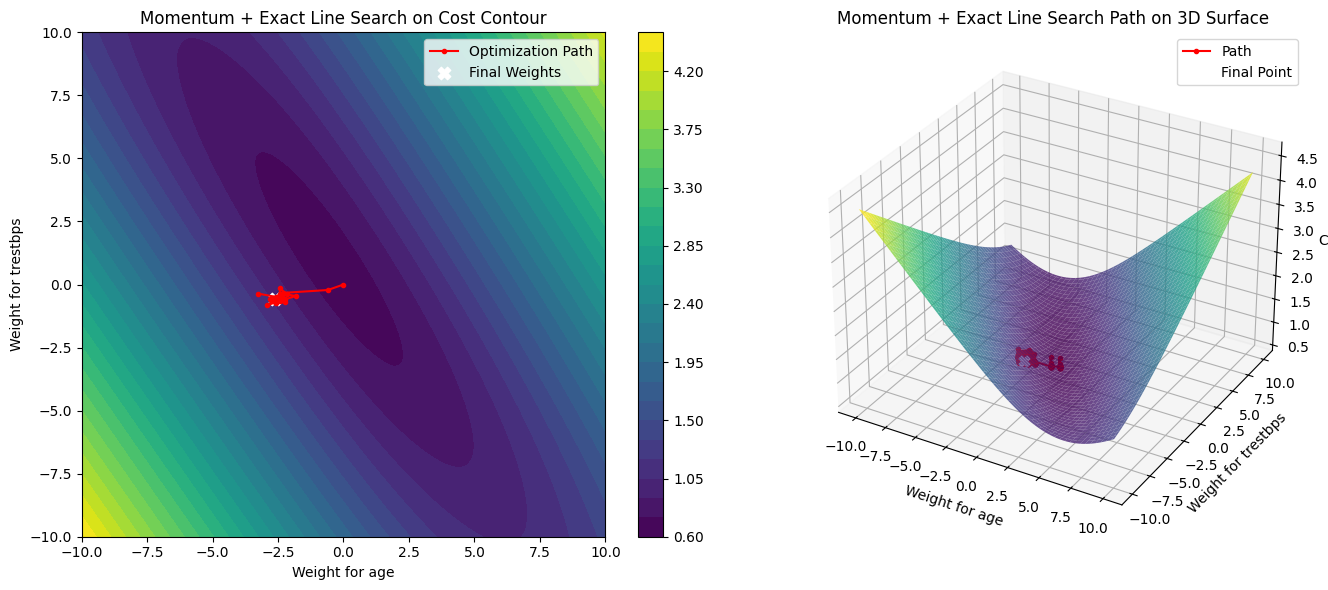

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize_scalar

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Exact Line Search Function ------------------
def exact_line_search(X, y, W, direction):
    """
    Finds the optimal learning rate (alpha) that minimizes cost along a given direction.
    """
    def cost_func(alpha):
        W_new = W - alpha * direction
        y_hat = sigmoid(np.dot(X, W_new))
        return compute_cost(y, y_hat)

    res = minimize_scalar(cost_func, bounds=(1e-6, 1), method='bounded')
    return res.x if res.success else 0.01  # fallback if optimization fails

# ------------------ Momentum Gradient Descent with Exact Line Search ------------------
def momentum_gd_exact_line_search(X, y, gamma=0.9, epochs=200, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    v = np.zeros_like(W)
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            z = np.dot(X_batch, W)
            y_hat = sigmoid(z)
            grad = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Compute optimal step size using exact line search
            lr = exact_line_search(X_batch, y_batch, W, grad)

            # Momentum update
            v = gamma * v + lr * grad
            W -= v

            if np.random.rand() < 0.005:
                path.append(W.copy())

        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f} | Step Size: {lr:.5f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_mgd, path_mgd, costs_mgd = momentum_gd_exact_line_search(X_train, y_train, gamma=0.9, epochs=200, batch_size=32)

# ------------------ Evaluate ------------------
y_pred_mgd = sigmoid(np.dot(X_test, W_mgd))
y_pred_class_mgd = (y_pred_mgd >= 0.5).astype(int)
accuracy_mgd = np.mean(y_pred_class_mgd == y_test) * 100
print(f"\n✅ Test Accuracy (Momentum + Exact Line Search): {accuracy_mgd:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with Path ------------------
fig = plt.figure(figsize=(14, 6))

# Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Momentum + Exact Line Search on Cost Contour", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_mgd[:, 1], path_mgd[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='Optimization Path')
ax1.scatter(W_mgd[1], W_mgd[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Momentum + Exact Line Search Path on 3D Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_mgd:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_mgd[:, 1], path_mgd[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='Path')
ax2.scatter(W_mgd[1], W_mgd[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

This method combines Momentum Gradient Descent with Exact Line Search, where the optimal step size is computed mathematically at each update instead of using a fixed learning rate.

Exact line search finds the learning rate that minimizes the cost along the gradient direction, leading to more precise and efficient updates.

The contour and 3D plots show how the optimizer takes smoother, well-scaled steps toward the minimum compared to fixed-LR momentum.

This approach improves stability, avoids overshooting, and often converges faster due to the mathematically optimal step size.

#Cost curves for all algorithms

Training all optimization algorithms...


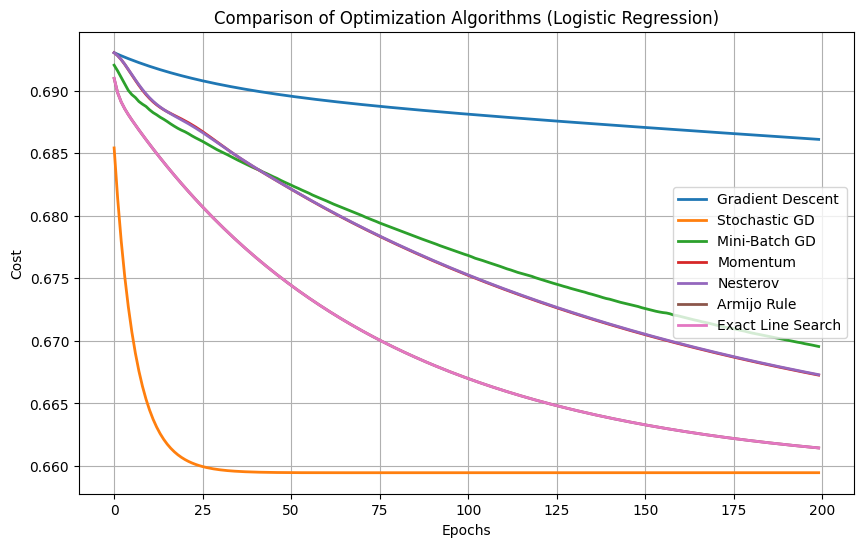

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# -------------------- Load and preprocess data --------------------
df = pd.read_csv("/content/heart_cleaned.csv")

features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# -------------------- Helper Functions --------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    y_hat = sigmoid(np.dot(X, W))
    return (1 / len(y)) * np.dot(X.T, (y_hat - y))

# -------------------- 1. Batch Gradient Descent --------------------
def gradient_descent(X, y, lr=0.05, epochs=200):
    W = np.zeros((X.shape[1], 1))
    costs = []
    for _ in range(epochs):
        grad = gradient(X, y, W)
        W -= lr * grad
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 2. Stochastic Gradient Descent --------------------
def stochastic_gd(X, y, lr=0.05, epochs=200):
    W = np.zeros((X.shape[1], 1))
    costs = []
    for _ in range(epochs):
        for i in range(len(y)):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = gradient(xi, yi, W)
            W -= lr * grad
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 3. Mini-Batch Gradient Descent --------------------
def mini_batch_gd(X, y, lr=0.05, epochs=200, batch_size=32):
    W = np.zeros((X.shape[1], 1))
    costs = []
    m = len(y)
    for _ in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        for i in range(0, m, batch_size):
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            grad = gradient(Xb, yb, W)
            W -= lr * grad
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 4. Momentum --------------------
def momentum(X, y, lr=0.05, gamma=0.9, epochs=200):
    W = np.zeros((X.shape[1], 1))
    v = np.zeros_like(W)
    costs = []
    for _ in range(epochs):
        grad = gradient(X, y, W)
        v = gamma * v + lr * grad
        W -= v
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 5. Nesterov Accelerated Gradient --------------------
def nesterov(X, y, lr=0.05, gamma=0.9, epochs=200):
    W = np.zeros((X.shape[1], 1))
    v = np.zeros_like(W)
    costs = []
    for _ in range(epochs):
        W_lookahead = W - gamma * v
        grad = gradient(X, y, W_lookahead)
        v = gamma * v + lr * grad
        W -= v
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 6. Armijo Rule --------------------
def armijo_rule(X, y, W, grad, beta=0.8, sigma=0.1, initial_lr=1):
    lr = initial_lr
    cost = compute_cost(y, sigmoid(np.dot(X, W)))
    while True:
        new_W = W - lr * grad
        new_cost = compute_cost(y, sigmoid(np.dot(X, new_W)))
        if new_cost <= cost - sigma * lr * np.sum(grad**2):
            break
        lr *= beta
        if lr < 1e-8:
            break
    return lr

def armijo_gd(X, y, epochs=200):
    W = np.zeros((X.shape[1], 1))
    costs = []
    for _ in range(epochs):
        grad = gradient(X, y, W)
        lr = armijo_rule(X, y, W, grad)
        W -= lr * grad
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- 7. Exact Line Search --------------------
def exact_line_search(X, y, W, grad):
    # Find step size minimizing cost along -grad direction
    alphas = np.linspace(0, 1, 30)
    costs = []
    for alpha in alphas:
        new_W = W - alpha * grad
        y_hat = sigmoid(np.dot(X, new_W))
        costs.append(compute_cost(y, y_hat))
    return alphas[np.argmin(costs)]

def exact_line_search_gd(X, y, epochs=200):
    W = np.zeros((X.shape[1], 1))
    costs = []
    for _ in range(epochs):
        grad = gradient(X, y, W)
        lr = exact_line_search(X, y, W, grad)
        W -= lr * grad
        y_hat = sigmoid(np.dot(X, W))
        costs.append(compute_cost(y, y_hat))
    return W, costs

# -------------------- Train all models --------------------
print("Training all optimization algorithms...")

_, cost_gd = gradient_descent(X_train, y_train)
_, cost_sgd = stochastic_gd(X_train, y_train)
_, cost_mbgd = mini_batch_gd(X_train, y_train)
_, cost_momentum = momentum(X_train, y_train)
_, cost_nag = nesterov(X_train, y_train)
_, cost_armijo = armijo_gd(X_train, y_train)
_, cost_exact = exact_line_search_gd(X_train, y_train)

# -------------------- Plot Cost Curves --------------------
plt.figure(figsize=(10, 6))
plt.plot(cost_gd, label="Gradient Descent", linewidth=2)
plt.plot(cost_sgd, label="Stochastic GD", linewidth=2)
plt.plot(cost_mbgd, label="Mini-Batch GD", linewidth=2)
plt.plot(cost_momentum, label="Momentum", linewidth=2)
plt.plot(cost_nag, label="Nesterov", linewidth=2)
plt.plot(cost_armijo, label="Armijo Rule", linewidth=2)
plt.plot(cost_exact, label="Exact Line Search", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Comparison of Optimization Algorithms (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

#Contour plots for all algorithms

Training optimizers...


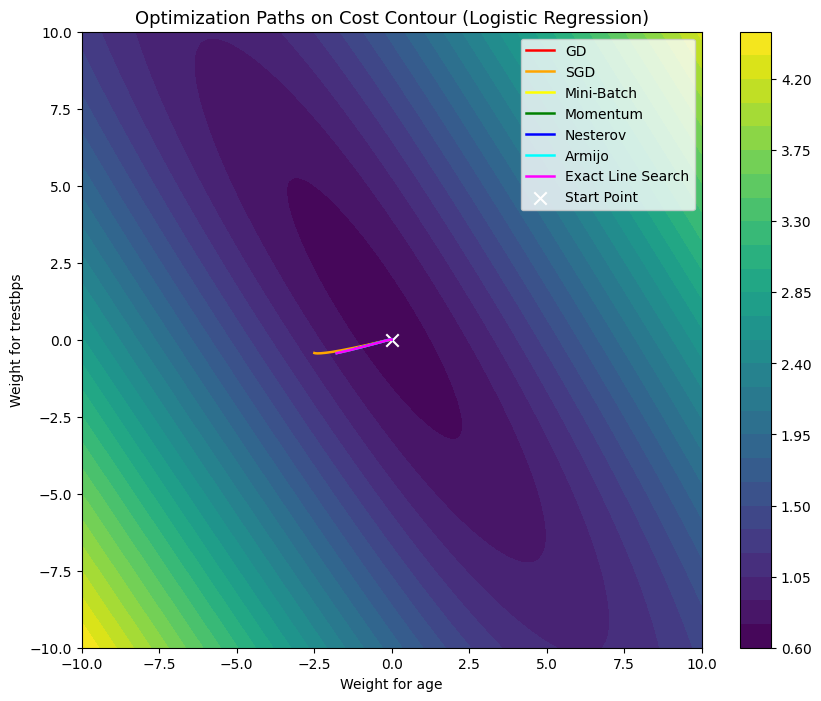

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load Dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    y_hat = sigmoid(np.dot(X, W))
    return (1 / len(y)) * np.dot(X.T, (y_hat - y))

# ------------------ Optimization Algorithms ------------------

def gradient_descent(X, y, lr=0.05, epochs=200):
    W = np.zeros((X.shape[1], 1))
    path = [W.copy()]
    for _ in range(epochs):
        grad = gradient(X, y, W)
        W -= lr * grad
        path.append(W.copy())
    return np.array(path)

def stochastic_gd(X, y, lr=0.05, epochs=200):
    W = np.zeros((X.shape[1], 1))
    path = [W.copy()]
    for _ in range(epochs):
        for i in range(len(y)):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = gradient(xi, yi, W)
            W -= lr * grad
        path.append(W.copy())
    return np.array(path)

def mini_batch_gd(X, y, lr=0.05, epochs=200, batch_size=32):
    W = np.zeros((X.shape[1], 1))
    m = len(y)
    path = [W.copy()]
    for _ in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        for i in range(0, m, batch_size):
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            grad = gradient(Xb, yb, W)
            W -= lr * grad
        path.append(W.copy())
    return np.array(path)

def momentum(X, y, lr=0.05, gamma=0.9, epochs=200):
    W = np.zeros((X.shape[1], 1))
    v = np.zeros_like(W)
    path = [W.copy()]
    for _ in range(epochs):
        grad = gradient(X, y, W)
        v = gamma * v + lr * grad
        W -= v
        path.append(W.copy())
    return np.array(path)

def nesterov(X, y, lr=0.05, gamma=0.9, epochs=200):
    W = np.zeros((X.shape[1], 1))
    v = np.zeros_like(W)
    path = [W.copy()]
    for _ in range(epochs):
        W_lookahead = W - gamma * v
        grad = gradient(X, y, W_lookahead)
        v = gamma * v + lr * grad
        W -= v
        path.append(W.copy())
    return np.array(path)

def armijo_rule(X, y, W, grad, beta=0.8, sigma=0.1, initial_lr=1):
    lr = initial_lr
    cost = compute_cost(y, sigmoid(np.dot(X, W)))
    while True:
        new_W = W - lr * grad
        new_cost = compute_cost(y, sigmoid(np.dot(X, new_W)))
        if new_cost <= cost - sigma * lr * np.sum(grad**2):
            break
        lr *= beta
        if lr < 1e-8:
            break
    return lr

def armijo_gd(X, y, epochs=200):
    W = np.zeros((X.shape[1], 1))
    path = [W.copy()]
    for _ in range(epochs):
        grad = gradient(X, y, W)
        lr = armijo_rule(X, y, W, grad)
        W -= lr * grad
        path.append(W.copy())
    return np.array(path)

def exact_line_search(X, y, W, grad):
    alphas = np.linspace(0, 1, 30)
    costs = []
    for alpha in alphas:
        new_W = W - alpha * grad
        y_hat = sigmoid(np.dot(X, new_W))
        costs.append(compute_cost(y, y_hat))
    return alphas[np.argmin(costs)]

def exact_line_search_gd(X, y, epochs=200):
    W = np.zeros((X.shape[1], 1))
    path = [W.copy()]
    for _ in range(epochs):
        grad = gradient(X, y, W)
        lr = exact_line_search(X, y, W, grad)
        W -= lr * grad
        path.append(W.copy())
    return np.array(path)

# ------------------ Train all algorithms ------------------
print("Training optimizers...")
paths = {
    "GD": gradient_descent(X_train, y_train),
    "SGD": stochastic_gd(X_train, y_train),
    "Mini-Batch": mini_batch_gd(X_train, y_train),
    "Momentum": momentum(X_train, y_train),
    "Nesterov": nesterov(X_train, y_train),
    "Armijo": armijo_gd(X_train, y_train),
    "Exact Line Search": exact_line_search_gd(X_train, y_train)
}

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour ------------------
plt.figure(figsize=(10, 8))
cp = plt.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
plt.colorbar(cp)
plt.title("Optimization Paths on Cost Contour (Logistic Regression)", fontsize=13)
plt.xlabel("Weight for age")
plt.ylabel("Weight for trestbps")

colors = ["red", "orange", "yellow", "green", "blue", "cyan", "magenta"]
for (name, path), color in zip(paths.items(), colors):
    plt.plot(path[:, 1], path[:, 2], color=color, linewidth=1.8, label=name)

plt.scatter(0, 0, color="white", marker="x", s=80, label="Start Point")
plt.legend()
plt.show()